# Linear Models

Check the performance of SVM and logistic regression on our engineered data sets before moving to more complex models.

In [10]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run


In [11]:
df = load_csv('linear_frame')

In [12]:
from shared_util.split import train_val_test_split

X_train, X_validate, X_test, y_train, y_validate, y_test = train_val_test_split(df)

In [13]:
from sklearn.model_selection import StratifiedKFold

def make_cv():
    return StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
    )



## Baseline Logistic Regression

In [14]:
from sklearn.linear_model import SGDClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

from shared_util.baseline import get_baseline_score
from imblearn.pipeline import Pipeline


print('Baseline SGD Classifier')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd',
        threshold_notes='base',
        data='train',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )



Baseline SGD Classifier
roc_auc_score score per fold:  [0.58972662 0.57770758 0.56849626 0.57223987 0.57267614 0.58163101
 0.58439605 0.55276184 0.57396423 0.56819297]
mean roc_auc_score score:  0.5741792559925873
logged row: (0, sgd, train, base, under_sample)


In [15]:
# try SMOTE
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='sgd',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )


Baseline ROC_AUC using SMOTE
roc_auc_score score per fold:  [0.50560044 0.50298368 0.50438753 0.50054844 0.50374362 0.50097144
 0.50156721 0.49975849 0.50006541 0.50101635]
mean roc_auc_score score:  0.5020642619787375
logged row: (0, sgd, train, base, SMOTE)


Interestingly, baseline SGD using under sampling performed worse than baseline random forest using the same, but when using SMOTE, the linear model slightly outperformed the baseline random forest model.

In [16]:
def make_base_sgd(use_smote=False):
    return Pipeline([
        ('sampler',SMOTE(random_state=42) if use_smote else RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42))
    ])

In [17]:
# hyperparam search for SGD
from sklearn.model_selection import RandomizedSearchCV



sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

rs = RandomizedSearchCV(
    estimator=make_base_sgd(),
    param_distributions=sgd_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=make_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train)

print(f'Best ROC_AUC (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Best ROC_AUC (cv): 0.6511040871996193
best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.651104,0.010074,"{'model__tol': 0.0001, 'model__shuffle': True,..."
1,2,0.650749,0.010950,"{'model__tol': 0.001, 'model__shuffle': True, ..."
2,3,0.650269,0.009628,"{'model__tol': 0.001, 'model__shuffle': True, ..."
3,4,0.650250,0.009877,"{'model__tol': 0.001, 'model__shuffle': True, ..."
4,5,0.650116,0.010049,"{'model__tol': 0.001, 'model__shuffle': True, ..."
5,6,0.649824,0.009378,"{'model__tol': 0.0001, 'model__shuffle': True,..."
6,7,0.649116,0.011380,"{'model__tol': 0.0001, 'model__shuffle': True,..."
7,8,0.648596,0.011727,"{'model__tol': 0.001, 'model__shuffle': True, ..."
8,9,0.644192,0.007848,"{'model__tol': 0.0001, 'model__shuffle': True,..."
9,10,0.643208,0.011046,"{'model__tol': 0.0001, 'model__shuffle': True,..."


In [18]:
# Best ROC_AUC (cv): 0.655269993641728
# best_params: {
#     'model__tol': 0.001, 
#     'model__shuffle': True, 
#     'model__penalty': 'l1', 
#     'model__max_iter': 1000, 
#     'model__loss': 'log_loss', 
#     'model__learning_rate': 'constant', 
#     'model__l1_ratio': 0.1, 
#     'model__eta0': 0.0003, ''
#     'model__class_weight': 'balanced', 
#     'model__average': False, 
#     'model__alpha': 0.0001
#     }

In [19]:
# predict on validate set before threshold changes
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring
from shared_util.metrics.printing import print_metrics

sgd_est = rs.best_estimator_
sgd_scores = get_scores(sgd_est, X_validate)

y_pred = rs.best_estimator_.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=sgd_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              data='validate',
              model='sgd',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6589232795819668
Accuracy:      0.6623151725056614
F1 score:      0.27155172413793105
Precision:     0.17976031957390146
Recall:        0.5549031121550205

Confusion matrix:

TN: 8999, FP: 4312, FN: 758, TP: 945

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     13311
           1       0.18      0.55      0.27      1703

    accuracy                           0.66     15014
   macro avg       0.55      0.62      0.53     15014
weighted avg       0.84      0.66      0.72     15014

logged row: (0, sgd, validate, base, under_sample)


Best threshold (F2): 0.4322
Precision: 0.149  Recall: 0.787  F2: 0.424


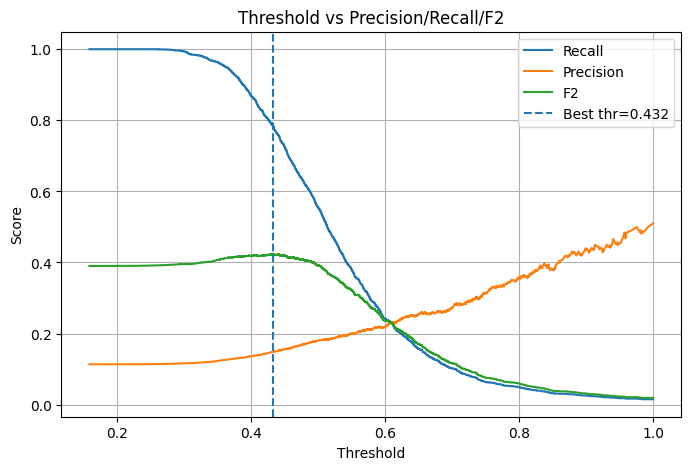

In [20]:
# decide threshold on validation set



info = best_threshold_by_fbeta(y_validate, sgd_scores, beta=2.0)
best_thresh = info['threshold']
y_pred_custom = (sgd_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [21]:
# use the threshold for predicitons on the held out test set

from shared_util.metrics.printing import print_metrics

sgd_scores_test = get_scores(sgd_est, X_test)

y_pred_custom_test = (sgd_scores_test >= best_thresh).astype(int)

print_metrics(
    y_true=y_test,
    y_pred=y_pred_custom_test,
    y_proba=sgd_scores_test,
    data='test',
    threshold_notes='f2_weighted',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRIC_NOTES,
    log=LOG,
    model='sgd',
    hyperparam_notes='tuned best ROC',
    pipeline_notes='under_sample'

)

ROC_AUC:     0.6578410783484873
Accuracy:      0.47332667332667333
F1 score:      0.24943052391799544
Precision:     0.1487771739130435
Recall:        0.7711267605633803

Confusion matrix:

TN: 5793, FP: 7518, FN: 390, TP: 1314

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.44      0.59     13311
           1       0.15      0.77      0.25      1704

    accuracy                           0.47     15015
   macro avg       0.54      0.60      0.42     15015
weighted avg       0.85      0.47      0.56     15015

logged row: (0, sgd, test, f2_weighted, under_sample)


In [22]:
# SVM
from sklearn.svm import SVC
from shared_util.baseline import get_baseline_score

roc_auc = get_baseline_score(
    SVC(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
)

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='svc',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )






roc_auc_score score per fold:  [0.62544294 0.60142927 0.5982024  0.59756963 0.60460774 0.59576717
 0.61472169 0.61106578 0.61601683 0.59989104]
mean roc_auc_score score:  0.6064714489542331
logged row: (0, svc, train, base, under_sample)


In [23]:
# running smote did not get a result after 6 hours so leaving it out for now

## Hyperparameter sweep for SVM

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV #type: ignore
from scipy.stats import loguniform



def make_base_svc():
    return Pipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42, cache_size=16384, probability=True))
    ])
# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf", "poly"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

# reduced to 5 folds again for computation time

cv_svc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

rs_hsvc = HalvingRandomSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
   # n_iter=50,  
    scoring='roc_auc',
    cv=make_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)



rs_hsvc.fit(X_train, y_train)

print(f'Best ROC_AUC (cv): {rs_hsvc.best_score_}')
print(f'Best params: {rs_hsvc.best_params_}')

res_df = pd.DataFrame(rs_hsvc.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 40
max_resources_: 70066
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1751
n_resources: 40
Fitting 10 folds for each of 1751 candidates, totalling 17510 fits
----------
iter: 1
n_candidates: 584
n_resources: 120
Fitting 10 folds for each of 584 candidates, totalling 5840 fits
----------
iter: 2
n_candidates: 195
n_resources: 360
Fitting 10 folds for each of 195 candidates, totalling 1950 fits
----------
iter: 3
n_candidates: 65
n_resources: 1080
Fitting 10 folds for each of 65 candidates, totalling 650 fits
----------
iter: 4
n_candidates: 22
n_resources: 3240
Fitting 10 folds for each of 22 candidates, totalling 220 fits
----------
iter: 5
n_candidates: 8
n_resources: 9720
Fitting 10 folds for each of 8 candidates, totalling 80 fits
----------
iter: 6
n_candidates: 3
n_resources: 29160
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Best ROC_AUC (cv): 0.6462496567

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.646250,0.015958,"{'model__C': 0.51664730665406, 'model__class_w..."
1,2,0.641540,0.016734,"{'model__C': 0.23825177763049873, 'model__clas..."
2,3,0.640683,0.016828,"{'model__C': 0.2144611387193578, 'model__class..."
3,4,0.637196,0.026885,"{'model__C': 0.51664730665406, 'model__class_w..."
4,5,0.632104,0.031024,"{'model__C': 0.23825177763049873, 'model__clas..."
5,6,0.631176,0.031106,"{'model__C': 0.2144611387193578, 'model__class..."
6,7,0.629062,0.031539,"{'model__C': 0.00305855080099663, 'model__clas..."
7,7,0.629062,0.031539,"{'model__C': 0.07887450193826899, 'model__clas..."
8,7,0.629062,0.031539,"{'model__C': 0.0014207404990676058, 'model__cl..."
9,7,0.629062,0.031539,"{'model__C': 0.030382212996456274, 'model__cla..."


In [25]:
# The above code block generates best hyperparams for our SVC model:

# Best ROC_AUC (cv): 0.6333948470860357
# Best params: {'model__C': np.float64(0.1768787611314103), 'model__class_weight': 'balanced', 'model__gamma': 0.01, 'model__kernel': 'rbf', 'model__shrinking': False}

In [26]:
# predict on validate set before threshold changes
svm_est = rs_hsvc.best_estimator_
svm_scores = get_scores(svm_est, X_validate)

y_pred = svm_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=svm_scores,
              data='validate',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6557317329192281
Accuracy:      0.6944851471959504
F1 score:      0.2685377132833679
Precision:     0.18432574430823118
Recall:        0.4944216089254257

Confusion matrix:

TN: 9585, FP: 3726, FN: 861, TP: 842

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.72      0.81     13311
           1       0.18      0.49      0.27      1703

    accuracy                           0.69     15014
   macro avg       0.55      0.61      0.54     15014
weighted avg       0.83      0.69      0.75     15014

logged row: (0, svc, validate, base, under_sample)


Best threshold (F2): 0.4357
Precision: 0.161  Recall: 0.710  F2: 0.423


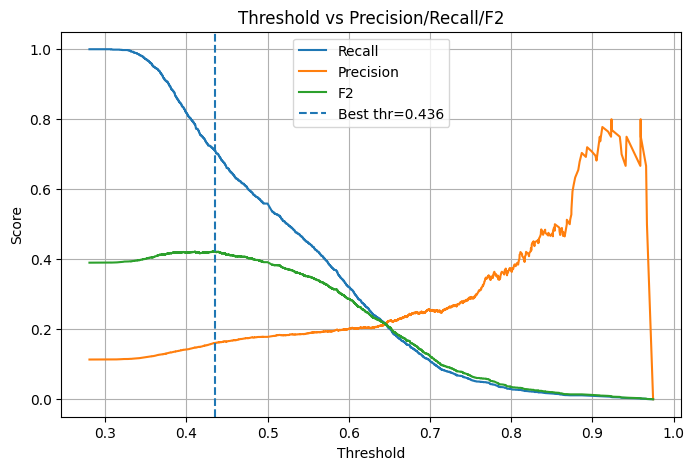

In [27]:
# threshold sweep using validation set
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring



info = best_threshold_by_fbeta(y_validate, svm_scores, beta=2.0)

best_thresh = info["threshold"]
y_pred_custom = (svm_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [28]:
# held out test prediction using calculated threshold

# this inference took ~25 seconds, considering other models took <1 second, thats a significant downside to SVC

svm_scores_test = get_scores(svm_est, X_test)

y_pred_test_svm = (svm_scores_test >= best_thresh).astype(int)


In [29]:
from shared_util.metrics.printing import print_metrics

print ('Held out test metrics for (Support Vector Classifier)')

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test_svm, 
              y_proba=svm_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
              )

Held out test metrics for (Support Vector Classifier)
ROC_AUC:     0.6546909074460283
Accuracy:      0.5537795537795538
F1 score:      0.2624394539850286
Precision:     0.16151761517615176
Recall:        0.6995305164319249

Confusion matrix:

TN: 7123, FP: 6188, FN: 512, TP: 1192

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.54      0.68     13311
           1       0.16      0.70      0.26      1704

    accuracy                           0.55     15015
   macro avg       0.55      0.62      0.47     15015
weighted avg       0.85      0.55      0.63     15015

logged row: (0, svc, test, f2_weighted, under_sample)


Both SVM and the SGD classifier both achieved above expected results compared to previous literature, which showed linear models performing, generally, with a ROC_AUC below 0.600.

